In [1]:
import asyncio
import base64
import re
import time
from io import BytesIO
from pathlib import Path

from IPython.display import display
from openai import AsyncOpenAI
from PIL import Image
from tqdm.auto import tqdm

# ── Server ──
VLLM_BASE  = "http://localhost:8010/v1"
VLLM_MODEL = "MY_MODEL"

# ── Task ──
images_dir     = Path("../Untitled_Folder")
MAX_NEW_TOKENS = 256
CONCURRENCY    = 16   # keep <= server --max-num-seqs

# ── Prompt A — tag list ──
PROMPT_TAGS = """You are an image tagger.

The image is a crop. List only what is clearly visible in the crop.

Rules:
- English, short nouns (1–4 words).
- Do not guess. If unsure, omit.
- No duplicates. Maximum 10 items.

OUTPUT FORMAT (required):
Respond with ONE single line starting exactly with:
Image Tags:
followed by tags separated by " | " (space-pipe-space).

Example:
Image Tags: pen | desk | paper | wood

No JSON. No markdown. No explanation. No reasoning."""

# ── Prompt B — object description ──
PROMPT_DESCRIBE = """You are an object identification assistant.

The image is a crop from a bounding box detected in a room scene.

Your task:
1. Identify the MAIN object in the crop (the primary subject of the bounding box).
2. Only if relevant, briefly mention the most important secondary details (e.g. notable items on or around the main object).

Rules:
- English only.
- Be concise. One or two sentences maximum.
- Do not list every visible item — focus on what matters most.
- Do not guess. If the main object is unclear, say so.

OUTPUT FORMAT (required):
Respond with exactly two lines:
Object: <main object name>
Description: <one or two sentence description>

No JSON. No markdown. No extra text. No reasoning."""

/home/pressprexx/miniconda3/envs/Qwen9B/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}


def collect_images(directory: Path) -> list[Path]:
    paths = sorted(p for p in directory.iterdir()
                   if p.is_file() and p.suffix.lower() in IMAGE_EXTS)
    if not paths:
        raise FileNotFoundError(f"No images found in {directory}")
    return paths


def encode_image_b64(path: Path, quality: int = 85) -> str:
    img = Image.open(path).convert("RGB")
    buf = BytesIO()
    img.save(buf, format="JPEG", quality=quality)
    return base64.b64encode(buf.getvalue()).decode()


def build_messages(path: Path, prompt: str) -> list[dict]:
    b64 = encode_image_b64(path)
    return [{"role": "user", "content": [
        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
        {"type": "text", "text": prompt},
    ]}]


def parse_tags(text: str) -> list[str]:
    m = re.search(r"Image Tags:\s*(.+)", text, re.IGNORECASE)
    if not m:
        return []
    return [t.strip() for t in m.group(1).split("|") if t.strip()]


def parse_description(text: str) -> tuple[str, str]:
    obj  = re.search(r"Object:\s*(.+)",      text, re.IGNORECASE)
    desc = re.search(r"Description:\s*(.+)", text, re.IGNORECASE | re.DOTALL)
    return (
        obj.group(1).strip()  if obj  else "(unknown)",
        desc.group(1).strip() if desc else text.strip(),
    )


def print_token_stats(results: list[tuple], max_model_len: int = 16384) -> None:
    all_in  = [r[3] for r in results]
    all_out = [r[4] for r in results]
    peak    = max(i + o for i, o in zip(all_in, all_out))
    print(f"Token usage across {len(results)} images:")
    print(f"  Input  — min={min(all_in)}  max={max(all_in)}  avg={sum(all_in)//len(all_in)}")
    print(f"  Output — min={min(all_out)}  max={max(all_out)}  avg={sum(all_out)//len(all_out)}")
    print(f"  Peak total per request (in+out): {peak}")
    print(f"  (--max-model-len is {max_model_len}; could reduce to ~{peak + 128} with headroom)")
    print()


REQUEST_TIMEOUT = 10.0   # seconds; timed-out calls are retried once then skipped


async def _call(client, messages) -> tuple[str, int, int]:
    """Single API call; returns (text, in_tok, out_tok)."""
    resp    = await client.chat.completions.create(
        model=VLLM_MODEL,
        messages=messages,
        max_tokens=MAX_NEW_TOKENS,
        temperature=0.0,
        extra_body={"repetition_penalty": 1.05},
    )
    text    = resp.choices[0].message.content or ""
    usage   = resp.usage
    return text, (usage.prompt_tokens if usage else 0), (usage.completion_tokens if usage else 0)


async def infer_one(client, sem, path: Path, prompt: str) -> tuple:
    messages = build_messages(path, prompt)
    async with sem:
        for attempt in range(2):   # try once, retry once on timeout
            t0 = time.perf_counter()
            try:
                text, in_tok, out_tok = await asyncio.wait_for(
                    _call(client, messages), timeout=REQUEST_TIMEOUT
                )
                elapsed = time.perf_counter() - t0
                return path, text, elapsed, in_tok, out_tok
            except asyncio.TimeoutError:
                elapsed = time.perf_counter() - t0
                if attempt == 0:
                    print(f"\n  [timeout {elapsed:.1f}s] retrying {path.name} …")
                else:
                    print(f"\n  [timeout {elapsed:.1f}s] skipping {path.name}")
                    return path, "[TIMEOUT]", elapsed, 0, 0


async def run_all(paths: list[Path], prompt: str) -> list[tuple]:
    client = AsyncOpenAI(base_url=VLLM_BASE, api_key="none")
    sem    = asyncio.Semaphore(CONCURRENCY)
    tasks  = [infer_one(client, sem, p, prompt) for p in paths]
    out    = []
    with tqdm(total=len(tasks), unit="img") as bar:
        for coro in asyncio.as_completed(tasks):
            out.append(await coro)
            bar.update(1)
    return out

## Section 1 — Inference

Runs both prompts on every image in the folder. Make sure the vLLM server is running before executing these cells.

In [ ]:
# ── Run A: tag list ──────────────────────────────────────────────────────────
paths = collect_images(images_dir)
print(f"Images found: {len(paths)}\n")

t_start  = time.perf_counter()
results_tags = await run_all(paths, PROMPT_TAGS)
t_total  = time.perf_counter() - t_start

print(f"Total time : {t_total:.2f} s  ({t_total / len(results_tags):.3f} s/img)\n")
print_token_stats(results_tags)

for path, raw, elapsed, in_tok, out_tok in sorted(results_tags, key=lambda r: r[0].name):
    tags    = parse_tags(raw)
    tag_str = " | ".join(tags) if tags else "(none)"
    print(f"{path.name}  [{elapsed:.2f}s  in={in_tok} out={out_tok}]")
    display(Image.open(path))
    print(f"  Tags: {tag_str}")
    print(f"  RAW:  {raw.strip()}")
    print()

In [4]:
# ── Run B: object description ─────────────────────────────────────────────
t_start = time.perf_counter()
results_desc = await run_all(paths, PROMPT_DESCRIBE)
t_total = time.perf_counter() - t_start

print(f"Total time : {t_total:.2f} s  ({t_total / len(results_desc):.3f} s/img)\n")
print_token_stats(results_desc)

for path, raw, elapsed, in_tok, out_tok in sorted(results_desc, key=lambda r: r[0].name):
    obj, desc = parse_description(raw)
    print(f"{path.name}  [{elapsed:.2f}s  in={in_tok} out={out_tok}]")
    display(Image.open(path))
    print(f"  Object:      {obj}")
    print(f"  Description: {desc}")
    print(f"  RAW:         {raw.strip()}")
    print()

## Section 2 — Embedding & Vector Store


In [5]:
import pickle
import faiss
import torch
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B",
    device="cuda",
    model_kwargs={"torch_dtype": torch.float16},
    tokenizer_kwargs={"padding_side": "left"},
)

texts = []
metadata = []
for path_img, raw, elapsed, in_tok, out_tok in results_desc:
    obj, desc = parse_description(raw)
    texts.append(f"{obj}: {desc}")
    metadata.append({"id": path_img.stem, "object": obj,
                     "description": desc, "image_path": str(path_img.resolve())})

embs  = model.encode(texts, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)
index = faiss.IndexFlatIP(embs.shape[1])
index.add(embs)

faiss.write_index(index, "objects.index")
with open("objects_meta.pkl", "wb") as f:
    pickle.dump(metadata, f)

print(f"Indexed {index.ntotal} objects.")


The `tokenizer_kwargs` argument was renamed and is now deprecated. Please use `processor_kwargs` instead.
Batches: 100%|██████████| 1/1 [00:00<00:00,  3.44it/s]

Indexed 31 objects.


1. Mechanical keyboard — This is a white mechanical keyboard featuring a black and white anime-style illustration of a character on its surface.


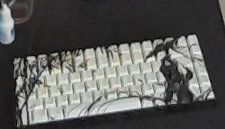


2. Mechanical keyboard — A white mechanical keyboard with black decorative patterns sits on a dark desk mat, surrounded by various office supplies like a mug and tissue box.


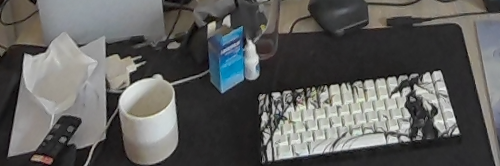


3. Gaming setup — The main object is a gaming desk featuring a steering wheel controller, a white keyboard, and a mouse on a large mousepad.


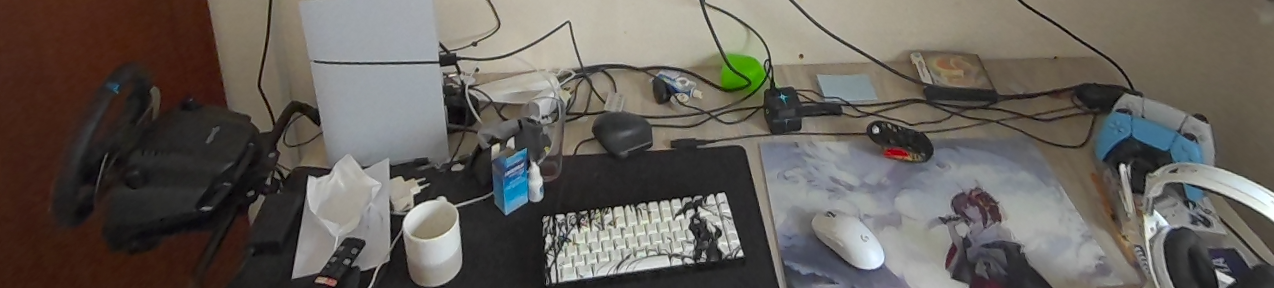


4. Desk setup — The main object is a cluttered desk featuring a white keyboard, mouse, and large mousepad with anime artwork, surrounded by various electronics and accessories.


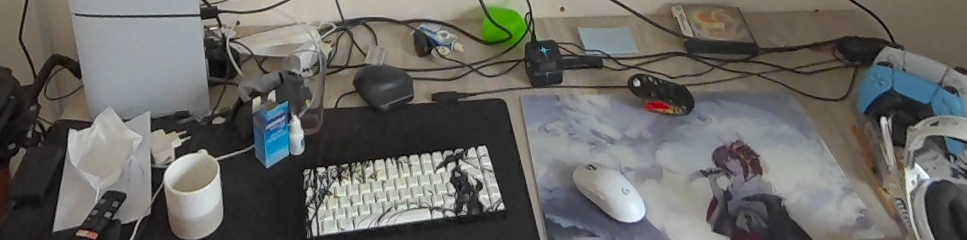


5. Game controller — A blue and black game controller is visible, resting on a light-colored surface with some cables nearby.


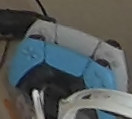

In [6]:
import pickle
import faiss

index = faiss.read_index("objects.index")
with open("objects_meta.pkl", "rb") as f:
    metadata = pickle.load(f)

def search(query, k=5):
    emb = model.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    _, indices = index.search(emb, k)
    return [metadata[i] for i in indices[0]]

QUERY = "a keyboard"
TOP_K = 5

for i, r in enumerate(search(QUERY, TOP_K), 1):
    print(f"{i}. {r['object']} — {r['description']}")
    display(Image.open(r["image_path"]))
    print()
